# How to make your own benchmark?
This notebook shows an example of how to use the benchmark defition to write a new benchmark class.

Here we make a simple benchmark that creates two circuits, one that prepares all the qubits in the ground state and another one that prepares them in the excited state.

In [51]:
# Define a new benchmark here.
import xarray as xr
from iqm.benchmarks.benchmark_definition import (
    Benchmark,
    BenchmarkConfigurationBase,
    add_counts_to_dataset,
    BenchmarkAnalysisResult,
)

from iqm.benchmarks.utils import (
    xrvariable_to_counts,
)

from iqm.qiskit_iqm.iqm_provider import IQMBackend, IQMFakeBackend
from qiskit import QuantumCircuit, transpile
import matplotlib.pyplot as plt

def generate_readout_test_circuit(backend, N_qubits):
    circuits=[]
    qb_to_measure = range(N_qubits)

    qc = QuantumCircuit(N_qubits,N_qubits)
    for qubit in range(N_qubits):
        pass
    qc.barrier()
    qc.measure(qb_to_measure,qb_to_measure)
    circuits.append(qc)

    qc = QuantumCircuit(N_qubits,N_qubits)
    for qubit in range(N_qubits):
        qc.x(qubit)
    qc.barrier()
    qc.measure(qb_to_measure,qb_to_measure)
    circuits.append(qc)
    qc_transpiled = transpile(circuits, backend, optimization_level=0)
    return qc_transpiled


def plot_histogram(
    dataset: xr.Dataset,
):
    fig = plt.figure()
    for ii in range(50):
        try:
            plt.bar(dataset[f"test_state_{ii}"], dataset[f"test_counts_{ii}"], label=f"circuit={ii}")
        except:
           break
    plt.xticks(rotation=90)
    plt.legend()
    plt.close()
    return fig

def add_all_meta_to_dataset(self, dataset: xr.Dataset) -> None:
    """Adds all configuration metadata and circuits to the dataset variable.

    Args:
        dataset: The xarray dataset

    """
    # Add here any custom metadata you want to add to the dataset attributes:
    # dataset.attrs["session_timestamp"] = self.session_timestamp

    # Automatically store the configuration
    for key, value in self.configuration:
        if key == "benchmark":  # Avoid saving the class object
            dataset.attrs[key] = value.name
        else:
            dataset.attrs[key] = value


def readout_analysis(run):
    dataset = run.dataset

    # You can optionally convert the dataset variable to counts format using the utils function:
    n_circuits = len(dataset)
    all_counts = xrvariable_to_counts(dataset, "test", n_circuits)

    plots={}
    plots["histogram"] = plot_histogram(dataset)
    return BenchmarkAnalysisResult(dataset=dataset, plots=plots)

class ReadoutTest(Benchmark):

    analysis_function = staticmethod(readout_analysis)

    @classmethod
    def name(cls) -> str:
        """Returns the name of the benchmark."""
        return "readout_test"

    def __init__(self, backend: IQMBackend | IQMFakeBackend | str, configuration: "TestConfiguration"):
        super().__init__(backend, configuration)

    def execute(self, backend: IQMBackend | IQMFakeBackend) -> xr.Dataset:
        """
        Executes the benchmark.
        """
        dataset = xr.Dataset()
        circuits = generate_readout_test_circuit(backend, self.configuration.N_qubits)
        job = backend.run(circuits, shots=self.shots)
        identifier="test" # How to name your circuits in the dataset to distinguish them, for i.e. analysis of different layouts.
        dataset,_ = add_counts_to_dataset(job.result().get_counts(), identifier, dataset)
        add_all_meta_to_dataset(self, dataset)
        return dataset

class TestConfiguration(BenchmarkConfigurationBase):
    """Test case cofiguration, add any arguments here that are not already defined in the base class.

    Attributes:
        benchmark: ReadoutTest benchmark class.
        N_qubits: Number of qubits to prepare in the circuits.

    """

    benchmark: type[Benchmark] = ReadoutTest
    N_qubits: int = 5


In [52]:
from iqm.qiskit_iqm import IQMProvider
from iqm.qiskit_iqm.fake_backends.fake_apollo import IQMFakeApollo
import os

# Real backend
# token = ""
# os.environ["IQM_TOKEN"] = token
# quantum_computer = "garnet" # provide actual quantum computer name
# iqm_server_url = "https://resonance.meetiqm.com/" # provide actual IQM server URL
# os.environ["IQM_SERVER_URL"] = iqm_server_url
#
# provider = IQMProvider(iqm_server_url, quantum_computer=quantum_computer)
# backend = provider.get_backend()

#Fake backend
backend = IQMFakeApollo()


benchmark = ReadoutTest(backend, TestConfiguration(N_qubits=5, shots=1000))
run_result = benchmark.run()

2026-02-24 14:24:39,203 - iqm.benchmarks.logging_config - INFO - Adding counts to dataset


In [53]:
run_result.dataset

<xarray.Dataset> Size: 868B
Dimensions:        (test_state_0: 15, test_state_1: 16)
Coordinates:
  * test_state_0   (test_state_0) <U5 300B '00000' '00001' ... '10010' '10100'
  * test_state_1   (test_state_1) <U5 320B '00111' '01011' ... '11110' '11111'
Data variables:
    test_counts_0  (test_state_0) int64 120B 753 49 46 1 46 3 2 ... 1 1 41 2 2 2
    test_counts_1  (test_state_1) int64 128B 2 2 1 4 44 1 1 ... 5 48 4 47 36 765
Attributes:
    benchmark:               <bound method ReadoutTest.name of <class '__main...
    shots:                   1000
    max_gates_per_batch:     None
    max_circuits_per_batch:  None
    routing_method:          sabre
    physical_layout:         fixed
    use_dd:                  False
    dd_strategy:             None
    active_reset_cycles:     None
    N_qubits:                5

2026-02-24 14:24:39,460 - matplotlib.category - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-02-24 14:24:39,463 - matplotlib.category - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-02-24 14:24:39,474 - matplotlib.category - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


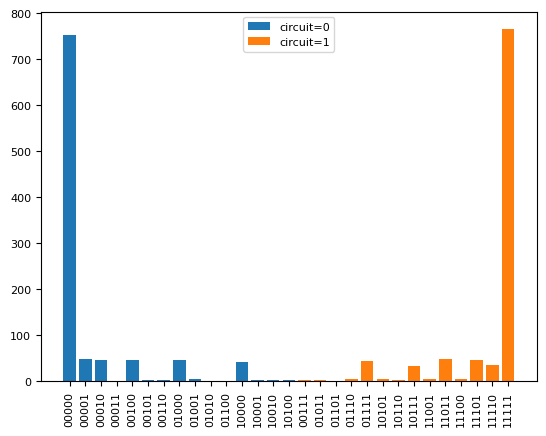

In [54]:
result = benchmark.analyze()
result.plot_all()